In [14]:
import os
import pandas as pd
import time
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, roc_auc_score
from scr.qsvdd_core.data_loader import QuantumDataLoader

# Credit Card Fraud Detection

## Global Configurations & Constants

Key hyperparameters and settings shared across the full pipeline:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `dataset` | `'fraud'` | Dataset identifier used internally |
| `n_train` | `0` | Number of training anomalies (one-class: only normals) |
| `latent_dim` | `3` | Dimensionality of the quantum latent space |
| `cost_func` | `'svdd'` | Loss function — SVDD hypersphere objective |
| `learning_rate` | `0.001` | Optimizer step size for all ansatzes |

## Dataset Loading and Exploratory Data Analysis (EDA)

We use the [Kaggle Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). It contains **284,807 transactions** made by European cardholders in September 2013, with **492 fraud cases** (~0.17%).

**Feature overview:**
- `Time`: Seconds elapsed since the first transaction.
- `V1–V28`: Principal components obtained via PCA (original features are confidential).
- `Amount`: Transaction amount (not PCA-transformed).
- `Class`: Target label — `0` = legitimate, `1` = fraud.

In [3]:
print("Current directory:", os.getcwd())
print("Files in this folder:", os.listdir())

Current directory: C:\Users\jeffe\Documents\GitHub\HE-Quantum-Anomaly-Detection\notebooks
Files in this folder: ['circuit_visualization.ipynb', 'classic_occ_algorithms.ipynb', 'noise_data_visualization.ipynb', 'training_test_data.ipynb', 'training_test_data_with_pca.ipynb', 'views.ipynb']


In [5]:
file_path = os.path.join("..", "data", "creditcard.csv")
df = pd.read_csv(file_path)

print("Dataset loaded successfully!\n")
print("First 5 records:\n", df.head())

Dataset loaded successfully!

First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.14126

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


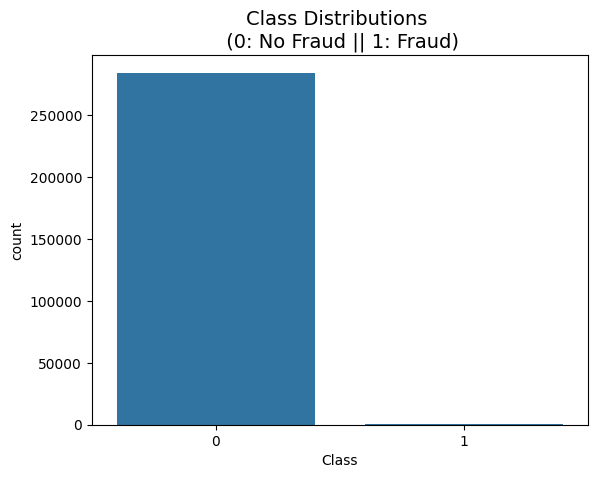

In [8]:
plt.style.use('default')

sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

plt.show()

In [9]:
tmp = df[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']

In [10]:
class_0.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [11]:
class_1.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [15]:
loader = QuantumDataLoader()

X_data, y = loader.prepare_classic_data(df)

print(f"Features for the circuit: {X_data.shape}")
print(f"Labels: {y.shape}")

Features for the circuit: (284807, 30)
Labels: (284807,)


In [20]:
"""
One-class Training (Classical):
Separation into normal and fraudulent examples.
The model will learn the representation of normality.
"""
# 1. Identify indices for each class
normal_indices = np.where(y == 0)[0]
abnormal_indices = np.where(y == 1)[0]
np.random.seed(42)

# 2. Training Set (X_train contains only legitimate transactions)
# Collect 1000 normal examples for training
X_train_normal_indices = np.random.choice(normal_indices, 1000, replace=False)
X_train = X_data[X_train_normal_indices]
Y_train = y[X_train_normal_indices]

# 3. Test Set (Balanced: 100 normal + 100 fraud)
# Remove indices already used in training to avoid data leakage
remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))

# Select 100 unseen normal samples and 100 fraud samples
X_test_normal_indices = np.random.choice(remaining_normal_indices, 100, replace=False)
X_test_abnormal_indices = np.random.choice(abnormal_indices, 100, replace=False)

X_test_normal = X_data[X_test_normal_indices]
y_test_normal = y[X_test_normal_indices]

X_test_abnormal = X_data[X_test_abnormal_indices]
y_test_abnormal = y[X_test_abnormal_indices]

# Create final test set with 200 examples (50% normal, 50% fraud)
X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)

# --- Note on Deep SVDD ---
# If running classical Deep SVDD, you will need a 'center'
# in the latent space. For IF, SVM, and LOF, this is not required.
# latent_dim_classic = X_data.shape[1]
# center_train = np.tile(np.zeros(latent_dim_classic), (len(X_train), 1))

print(f"X_train shape (Normal): {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test_normal shape: {X_test_normal.shape}")
print(f"X_test_abnormal shape: {X_test_abnormal.shape}")
print(f"X_test shape (Mix): {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape (Normal): (1000, 30)
Y_train shape: (1000,)
X_test_normal shape: (100, 30)
X_test_abnormal shape: (100, 30)
X_test shape (Mix): (200, 30)
Y_test shape: (200,)


In [21]:
# Dictionary to store results for each run
results = {
    "Isolation Forest": [],
    "One-Class SVM": [],
    "LOF": []
}

n_runs = 5

for i in range(n_runs):
    # Change seed for each run to ensure different samples
    current_seed = 42 + i
    np.random.seed(current_seed)

    # 1. Split data (Train: 1000 normal / Test: 100 normal + 100 fraud)
    normal_indices = np.where(y == 0)[0]
    abnormal_indices = np.where(y == 1)[0]

    idx_train = np.random.choice(normal_indices, 1000, replace=False)
    remaining_normal = list(set(normal_indices) - set(idx_train))

    idx_test_norm = np.random.choice(remaining_normal, 100, replace=False)
    idx_test_abnorm = np.random.choice(abnormal_indices, 100, replace=False)

    X_train_run = X_data[idx_train]
    X_test_run = np.concatenate((X_data[idx_test_norm], X_data[idx_test_abnorm]), axis=0)
    y_test_run = np.concatenate((np.zeros(100), np.ones(100)), axis=0)

    # 2. Instantiate Models
    models = {
        "Isolation Forest": IsolationForest(n_estimators=100, contamination=0.01, random_state=current_seed),
        "One-Class SVM": OneClassSVM(kernel='rbf', nu=0.1, gamma='scale'),
        "LOF": LocalOutlierFactor(n_neighbors=20, novelty=True)
    }

    # 3. Train and Evaluate
    for name, model in models.items():
        model.fit(X_train_run)

        # For AUC, we need decision scores rather than binary classes
        if name == "LOF":
            # Invert scores as lower values indicate anomalies in LOF
            y_scores = -model.decision_function(X_test_run)
        else:
            # Invert decision_function (which returns negative for anomalies)
            # so that higher scores = higher probability of fraud
            y_scores = -model.decision_function(X_test_run)

        auc = roc_auc_score(y_test_run, y_scores)
        results[name].append(auc)

# 4. Display Means and Standard Deviation in a formatted table
print(f"\n{'='*55}")
print(f"{'Classical Algorithm':<25} | {'Mean AUC':<12} | {'Std AUC':<10}")
print(f"{'-'*25}-|-{'-'*12}-|-{'-'*10}")

for name, scores in results.items():
    mean_auc = np.mean(scores)
    std_auc = np.std(scores)
    print(f"{name:<25} | {mean_auc:<12.4f} | {std_auc:<10.4f}")

print(f"{'='*55}\n")


Classical Algorithm       | Mean AUC     | Std AUC   
--------------------------|--------------|-----------
Isolation Forest          | 0.9615       | 0.0088    
One-Class SVM             | 0.9648       | 0.0081    
LOF                       | 0.9674       | 0.0038    



In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary


latent_dim = 3

class SVDD(nn.Module):
    def __init__(self, latent_dim, num_filters=3):
        super(SVDD, self).__init__()
        self.num_filters = num_filters
        self.latent_dim = latent_dim
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=self.num_filters, kernel_size=2, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(num_features=self.num_filters)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv1d(in_channels=self.num_filters, out_channels=self.num_filters, kernel_size=2, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(num_features=self.num_filters)
        self.conv3 = nn.Conv1d(in_channels=self.num_filters, out_channels=2, kernel_size=2, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(num_features=2)

        self.fc1 = nn.Linear(8, self.latent_dim)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x



x_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)


train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1)


svdd = SVDD(latent_dim=latent_dim)

svdd = svdd.cuda()

input_size = (1, 30)
summary(svdd, input_size=input_size)

weight_decay = 0.001
optimizer = torch.optim.Adam(svdd.parameters(), lr=0.001, weight_decay=weight_decay)
loss_history = []

c = None

def initialize_center_c(dataloader, model):
    model.eval()
    with torch.no_grad():
        n_samples = 0
        center = torch.zeros(model.latent_dim, device=next(model.parameters()).device)
        for data in dataloader:
            inputs, _ = data
            inputs = inputs.unsqueeze(1).cuda()
            outputs = model(inputs)
            center += torch.sum(outputs, dim=0)
            center /= outputs.shape[0]
            break
    model.train()
    return center

def train(num_steps):
    global c
    for step in range(num_steps):
        data = next(iter(train_dataloader))
        inputs, _ = data
        inputs = inputs.unsqueeze(1).cuda()
        optimizer.zero_grad()


        if c is None:
            c = initialize_center_c(train_dataloader, svdd)


        outputs = svdd(inputs)
        loss = torch.mean(torch.sum((outputs - c) ** 2, dim=1))


        l2_reg = torch.tensor(0., device=inputs.device)
        for param in svdd.parameters():
            l2_reg += torch.norm(param)
        loss += weight_decay * l2_reg

        loss.backward()
        optimizer.step()


        loss_history.append(loss.item())


        if step % 10 == 0:
            print('Step: {} | Loss: {:.6f}'.format(step, loss.data))


train(num_steps=500)

AssertionError: Torch not compiled with CUDA enabled

# Breast Cancer anomaly Detection